In [19]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Paths
base = Path("d:/Capstone")
crop_csv = base / "Data" / "Crop_recommendation.csv"
crop_yield_csv = base / "Data" / "Crop_Yield.csv"
crop_yield_csv = base / "Data" / "Crop_Yield.csv"
market_models = {
    "rf": base / "models" / "random_forest_model.pkl",
    "dnn": base / "models" / "dnn_model.pkl",
    "hybrid_weights": base / "models" / "hybrid_weights.pkl",
    "dnn_scaler": base / "models" / "dnn_scaler.pkl",
    "scaler": base / "models" / "scaler.pkl",
    "encoder": base / "models" / "encoders.pkl",
    "meta": base / "models" / "model_metadata.json",
}
crop_artifact_dir = base / "models" / "crop_recommendation"
crop_artifact_dir.mkdir(parents=True, exist_ok=True)

# Load crop dataset
assert crop_csv.exists(), f"Missing {crop_csv}"
crop_df = pd.read_csv(crop_csv)
print("Crop data:", crop_df.shape, "classes:", crop_df["label"].nunique())

# Load yield data
assert crop_yield_csv.exists(), f"Missing {crop_yield_csv}"
yield_df = pd.read_csv(crop_yield_csv)
yield_dict = {}
for _, row in yield_df.iterrows():
    if row['Season'] != 'Total':
        crop = row['Crop']
        season = row['Season']
        yields = [row[f'Yield-{year}'] for year in ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26'] if pd.notna(row[f'Yield-{year}'])]
        if yields:
            yield_dict[(crop, season)] = yields[-1]  # latest yield in kg/ha
print("Loaded yield data for", len(yield_dict), "crop-season combinations")

# Load yield data
assert crop_yield_csv.exists(), f"Missing {crop_yield_csv}"
yield_df = pd.read_csv(crop_yield_csv)
yield_dict = {}
for _, row in yield_df.iterrows():
    if row['Season'] != 'Total':
        crop = row['Crop']
        season = row['Season']
        yields = [row[f'Yield-{year}'] for year in ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26'] if pd.notna(row[f'Yield-{year}'])]
        if yields:
            yield_dict[(crop, season)] = yields[-1]  # latest yield in kg/ha
print("Loaded yield data for", len(yield_dict), "crop-season combinations")

# Crop model (train or load)
rf_path = crop_artifact_dir / "rf.pkl"
scaler_path = crop_artifact_dir / "scaler.pkl"
le_path = crop_artifact_dir / "label_encoder.pkl"

# Load from model1/ to match Preprocessing.ipynb
model1_dir = base / "models" / "model1"
crop_rf_path = model1_dir / "best_crop_model.pkl"
crop_scaler_path = model1_dir / "scaler.pkl"
crop_le_path = model1_dir / "label_encoder.pkl"

if crop_rf_path.exists() and crop_scaler_path.exists() and crop_le_path.exists():
    crop_rf = joblib.load(crop_rf_path)
    crop_scaler = joblib.load(crop_scaler_path)
    crop_le = joblib.load(crop_le_path)
    print("Loaded crop recommender models from model1/")
else:
    print("Model1 models not found, training new...")
    X = crop_df[["N","P","K","temperature","humidity","ph","rainfall"]].values
    y = crop_df["label"].values
    crop_scaler = StandardScaler().fit(X)
    X_scaled = crop_scaler.transform(X)
    crop_le = LabelEncoder().fit(y)
    y_enc = crop_le.transform(y)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
    crop_rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    crop_rf.fit(X_train, y_train)
    y_pred = crop_rf.predict(X_test)
    print("Crop model accu:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=crop_le.classes_))
    joblib.dump(crop_scaler, scaler_path)
    joblib.dump(crop_le, le_path)
    joblib.dump(crop_rf, rf_path)
    print("Saved crop recommender models")

# Load market models
loaded_market_models = {}
for k, p in market_models.items():
    if p.exists():
        if k == "meta":
            loaded_market_models[k] = pd.read_json(p, typ='series').to_dict() if p.suffix == '.json' else None
            print("Loaded", k, "(JSON)")
        else:
            loaded_market_models[k] = joblib.load(p)
            print("Loaded", k)
    else:
        loaded_market_models[k] = None
        print("Missing market model artifact:", p.name)

# Extract label encoders from market_driven model artifacts if available
market_encoders = loaded_market_models.get("encoder") or {}
if isinstance(market_encoders, dict):
    crop_encoder = market_encoders.get("Crop") or market_encoders.get("crop")
    state_encoder = market_encoders.get("State") or market_encoders.get("state")
    season_encoder = market_encoders.get("Season") or market_encoders.get("season")
else:
    # For old format where encoder object is directly a sklearn encoder for crops
    crop_encoder = market_encoders
    state_encoder = None
    season_encoder = None

# Helper to map categories to encoded ids
def apply_encoder(enc, value, fallback=0):
    if enc is None:
        return fallback
    try:
        if hasattr(enc, 'transform'):
            return int(enc.transform([value])[0])
        if hasattr(enc, 'classes_'):
            return int(np.where(enc.classes_ == value)[0][0])
    except Exception:
        pass
    return fallback


def recommend_top_crop(sample, top_n=4):
    # sample: dict with N,P,K,temperature,humidity,ph,rainfall,state,season
    feature_array = np.array([[sample["N"], sample["P"], sample["K"], sample["temperature"], sample["humidity"], sample["ph"], sample["rainfall"]]])
    # For Random Forest, uses_scaled_features is true, so scale
    uses_scaled = True  # updated
    if uses_scaled:
        scaled = crop_scaler.transform(feature_array)
        proba = crop_rf.predict_proba(scaled)[0]
    else:
        proba = crop_rf.predict_proba(feature_array)[0]
    top_indices = np.argsort(proba)[-top_n:][::-1]
    recommendations = []
    for idx in top_indices:
        crop = crop_le.inverse_transform([idx])[0].title()
        prob = proba[idx]
        recommendations.append((crop, round(prob * 100, 2)))
    return recommendations

def forecast_price(crop, state, season):
    # Returns a price forecast using preloaded market models and encoders
    rf = loaded_market_models.get("rf")
    dnn = loaded_market_models.get("dnn")
    scaler = loaded_market_models.get("scaler")
    dnn_scaler = loaded_market_models.get("dnn_scaler")
    weights = loaded_market_models.get("hybrid_weights")
    if not all([rf, dnn, scaler, dnn_scaler, weights]):
        return None

    df = pd.DataFrame([{
        "Crop_enc": apply_encoder(crop_encoder, crop),
        "State_enc": apply_encoder(state_encoder, state),
        "Season_enc": apply_encoder(season_encoder, season),
        # Default placeholders in case these features are not available
        "Min_Price": 0.0,
        "Max_Price": 0.0,
        "Price_Spread": 0.0,
        "Price_Trend_30d": 0.0,
        "Cultivation_Cost": 0.0,
        "Profit_Margin": 0.0,
        "Commodity_Code": 0,
        "Month": 0,
        "Quarter": 0,
        "Year": 0,
        "Trend_Label_enc": 0
    }])

    try:
        if hasattr(scaler, 'feature_names_in_'):
            # Keep only features expected by scaler
            columns = scaler.feature_names_in_.tolist()
            df_scaled = df.reindex(columns=columns, fill_value=0)
        else:
            df_scaled = df

        x_scaled = scaler.transform(df_scaled.values)
        rf_pred = rf.predict(x_scaled)

        if hasattr(dnn_scaler, 'feature_names_in_'):
            columns_dnn = dnn_scaler.feature_names_in_.tolist()
            df_dnn_scaled = df.reindex(columns=columns_dnn, fill_value=0)
        else:
            df_dnn_scaled = df

        x_dnn_scaled = dnn_scaler.transform(df_dnn_scaled.values)
        dnn_pred = dnn.predict(x_dnn_scaled)

        y_pred = weights["w_rf"] * rf_pred + weights["w_dnn"] * dnn_pred
        return float(y_pred[0])
    except Exception as e:
        print("forecast_price error:", e)
        return None


# Cultivation cost per hectare (from market_driven config)
CULTIVATION_COST = {
    "Banana": 80000, "Papaya": 60000, "Mango": 45000, "Maize": 22000, "Water Melon": 40000,
    "Grapes": 120000, "Apple": 90000, "Rice": 15000, "Orange": 30000, "Pomegranate": 50000,
    "Cotton": 25000, "Coconut": 70000, "Lentil(Masur)(Whole)": 10000, "Jute": 18000,
    "Black Gram Dal(Urd Dal)": 12000, "Coffee": 80000, "Pegeon Pea(Arhar Fali)": 14000,
    # Add more if needed, default to 20000
}

def get_cultivation_cost(crop):
    return CULTIVATION_COST.get(crop, 20000)  # Default cost

def get_yield(crop, season):
    return yield_dict.get((crop, season), 2000)  # Default yield in kg/ha

def integrated_recommend(sample, top_n=4):
    recommended_crops = recommend_top_crop(sample, top_n=top_n)
    recommendations = []
    for crop, prob in recommended_crops:
        predicted_price = forecast_price(crop, sample.get("state",""), sample.get("season",""))
        cost = get_cultivation_cost(crop)
        yield_kg = get_yield(crop, sample.get("season",""))
        yield_quintals = yield_kg / 100  # kg/ha to quintals/ha
        revenue = predicted_price * yield_quintals if predicted_price else 0
        profit = revenue - cost
        # For future prediction, assume +5% price, cost same
        future_price = predicted_price * 1.05 if predicted_price else None
        future_revenue = future_price * yield_quintals if future_price else 0
        future_profit = future_revenue - cost
        recommendations.append({
            "crop": crop,
            "probability": prob,
            "predicted_price": predicted_price,
            "cultivation_cost": cost,
            "yield_kg_per_ha": yield_kg,
            "revenue": revenue,
            "profit": profit,
            "future_price": future_price,
            "future_revenue": future_revenue,
            "future_profit": future_profit
        })
    # Filter to only crops with price predictions
    recommendations = [r for r in recommendations if r["predicted_price"] is not None]
    # Select top 2 based on combined score: probability * profit (only for profitable crops)
    valid_recs = [r for r in recommendations if r["profit"] > 0]
    if len(valid_recs) >= 2:
        for r in valid_recs:
            r["score"] = r["probability"] * r["profit"]  # Higher score for better balance of suitability and profit
        valid_recs.sort(key=lambda x: x["score"], reverse=True)
        top_2 = valid_recs[:2]
    elif len(valid_recs) == 1:
        top_2 = valid_recs + [recommendations[0]]  # Add the highest prob even if not profitable
    else:
        top_2 = recommendations[:2]  # Fallback to top 2 by probability
    return {
        "top_recommendations": top_2,
        "all_recommendations": recommendations,
        "source": "integrated final_stage"
    }

# Example
demo_sample = {"N":90,"P":22,"K":43,"temperature":32.88,"humidity":82.0,"ph":6.5,"rainfall":202.93,"state":"Karnataka","season":"Kharif"}
result = integrated_recommend(demo_sample)
print("Top 2 Recommendations for Better Profits and Growth:")
for rec in result["top_recommendations"]:
    print(f"- {rec['crop']}: Prob {rec['probability']}%, Price ₹{rec['predicted_price']:.2f}, Cost ₹{rec['cultivation_cost']}, Profit ₹{rec['profit']:.2f}, Future Profit ₹{rec['future_profit']:.2f}")
print("\nAll Recommendations:")
for rec in result["all_recommendations"]:
    print(f"- {rec['crop']}: Prob {rec['probability']}%, Profit ₹{rec['profit']:.2f}")

Crop data: (2200, 8) classes: 22
Loaded yield data for 67 crop-season combinations
Loaded yield data for 67 crop-season combinations
Loaded crop recommender models from model1/
Loaded rf
Loaded dnn
Loaded hybrid_weights
Loaded dnn_scaler
Loaded scaler
Loaded encoder
Loaded meta (JSON)
Top 2 Recommendations for Better Profits and Growth:
- Rice: Prob 31.33%, Price ₹28394.83, Cost ₹15000, Profit ₹785450.25, Future Profit ₹825472.77
- Watermelon: Prob 19.0%, Price ₹1258.44, Cost ₹20000, Profit ₹5168.77, Future Profit ₹6427.20

All Recommendations:
- Rice: Prob 31.33%, Profit ₹785450.25
- Watermelon: Prob 19.0%, Profit ₹5168.77
- Coffee: Prob 15.0%, Profit ₹-15467.71
- Coconut: Prob 7.33%, Profit ₹-20472.72


## Notes for completing integration
1. Fill `forecast_price()` with the same encoding path as `market_driven.ipynb` (Crop_enc, State_enc, Season_enc, etc.).
2. Save final integration model path:
   - `d:/Capstone/models/final/`
   - `d:/Capstone/models/crop_recommendation/`
3. Optionally expose via Flask API:
   - `/api/v1/predict_recommendation`

In [20]:
# Debug: Check what crop the model predicts for the demo sample
demo_sample = {"N":90,"P":22,"K":43,"temperature":32.88,"humidity":82.0,"ph":6.5,"rainfall":202.93,"state":"Karnataka","season":"Kharif"}
feature_array = np.array([[demo_sample["N"], demo_sample["P"], demo_sample["K"], demo_sample["temperature"], demo_sample["humidity"], demo_sample["ph"], demo_sample["rainfall"]]])
print("Feature array:", feature_array)
scaled = crop_scaler.transform(feature_array)
proba = crop_rf.predict_proba(scaled)[0]
print("Proba:", proba[:5])  # first 5
top_indices = np.argsort(proba)[-4:][::-1]  # top 4
print("Top 4 predictions for demo sample:")
for idx in top_indices:
    crop = crop_le.inverse_transform([idx])[0].title()
    prob = proba[idx]
    print(f"{crop}: {prob:.4f}")

# Test with different samples
test_samples = [
    {"N":60,"P":55,"K":45,"temperature":22.0,"humidity":90.0,"ph":5.5,"rainfall":100.0},  # Should be rice-like
    {"N":20,"P":30,"K":10,"temperature":25.0,"humidity":65.0,"ph":7.0,"rainfall":50.0},   # Should be maize-like
    {"N":40,"P":20,"K":30,"temperature":30.0,"humidity":70.0,"ph":6.0,"rainfall":150.0}, # Should be cotton-like
]

for i, sample in enumerate(test_samples, 1):
    feature_array = np.array([[sample["N"], sample["P"], sample["K"], sample["temperature"], sample["humidity"], sample["ph"], sample["rainfall"]]])
    print(f"Feature array {i}:", feature_array)
    scaled = crop_scaler.transform(feature_array)
    proba = crop_rf.predict_proba(scaled)[0]
    print(f"Proba {i}:", proba[:5])
    top_indices = np.argsort(proba)[-4:][::-1]
    print(f"Top 4 predictions for test sample {i}:")
    for idx in top_indices:
        crop = crop_le.inverse_transform([idx])[0].title()
        prob = proba[idx]
        print(f"{crop}: {prob:.4f}")

# Check dataset for similar samples
print("\nDataset samples similar to input:")
similar = crop_df[(crop_df['N'].between(85,95)) & (crop_df['P'].between(15,30)) & (crop_df['K'].between(35,50)) & 
                  (crop_df['temperature'].between(30,35)) & (crop_df['humidity'].between(75,85)) & 
                  (crop_df['ph'].between(6,7)) & (crop_df['rainfall'].between(190,210))]
print(similar['label'].value_counts())

# Debug encoders
print("\nCrop encoder classes:")
if crop_encoder and hasattr(crop_encoder, 'classes_'):
    print(list(crop_encoder.classes_))
else:
    print("No crop_encoder or not sklearn encoder")

print("\nTesting apply_encoder for recommended crops:")
recommended_crops = ['Kidneybeans', 'Muskmelon', 'Orange', 'Mothbeans']
for crop in recommended_crops:
    enc_val = apply_encoder(crop_encoder, crop)
    print(f"{crop}: {enc_val}")

Feature array: [[ 90.    22.    43.    32.88  82.     6.5  202.93]]
Proba: [0.         0.05       0.         0.         0.07333333]
Top 4 predictions for demo sample:
Rice: 0.3133
Watermelon: 0.1900
Coffee: 0.1500
Coconut: 0.0733
Feature array 1: [[ 60.   55.   45.   22.   90.    5.5 100. ]]
Proba 1: [0.01   0.1575 0.     0.     0.    ]
Top 4 predictions for test sample 1:
Papaya: 0.3475
Rice: 0.2608
Banana: 0.1575
Jute: 0.1172
Feature array 2: [[20. 30. 10. 25. 65.  7. 50.]]
Proba 2: [0.    0.    0.015 0.    0.   ]
Top 4 predictions for test sample 2:
Mothbeans: 0.3417
Orange: 0.2200
Lentil: 0.2150
Mango: 0.0956
Feature array 3: [[ 40.  20.  30.  30.  70.   6. 150.]]
Proba 3: [0.    0.    0.    0.    0.325]
Top 4 predictions for test sample 3:
Mango: 0.3767
Coconut: 0.3250
Coffee: 0.1472
Pigeonpeas: 0.0593

Dataset samples similar to input:
Series([], Name: count, dtype: int64)

Crop encoder classes:
['Apple', 'Banana', 'Black Gram Dal(Urd Dal)', 'Coconut', 'Coffee', 'Cotton', 'Grapes

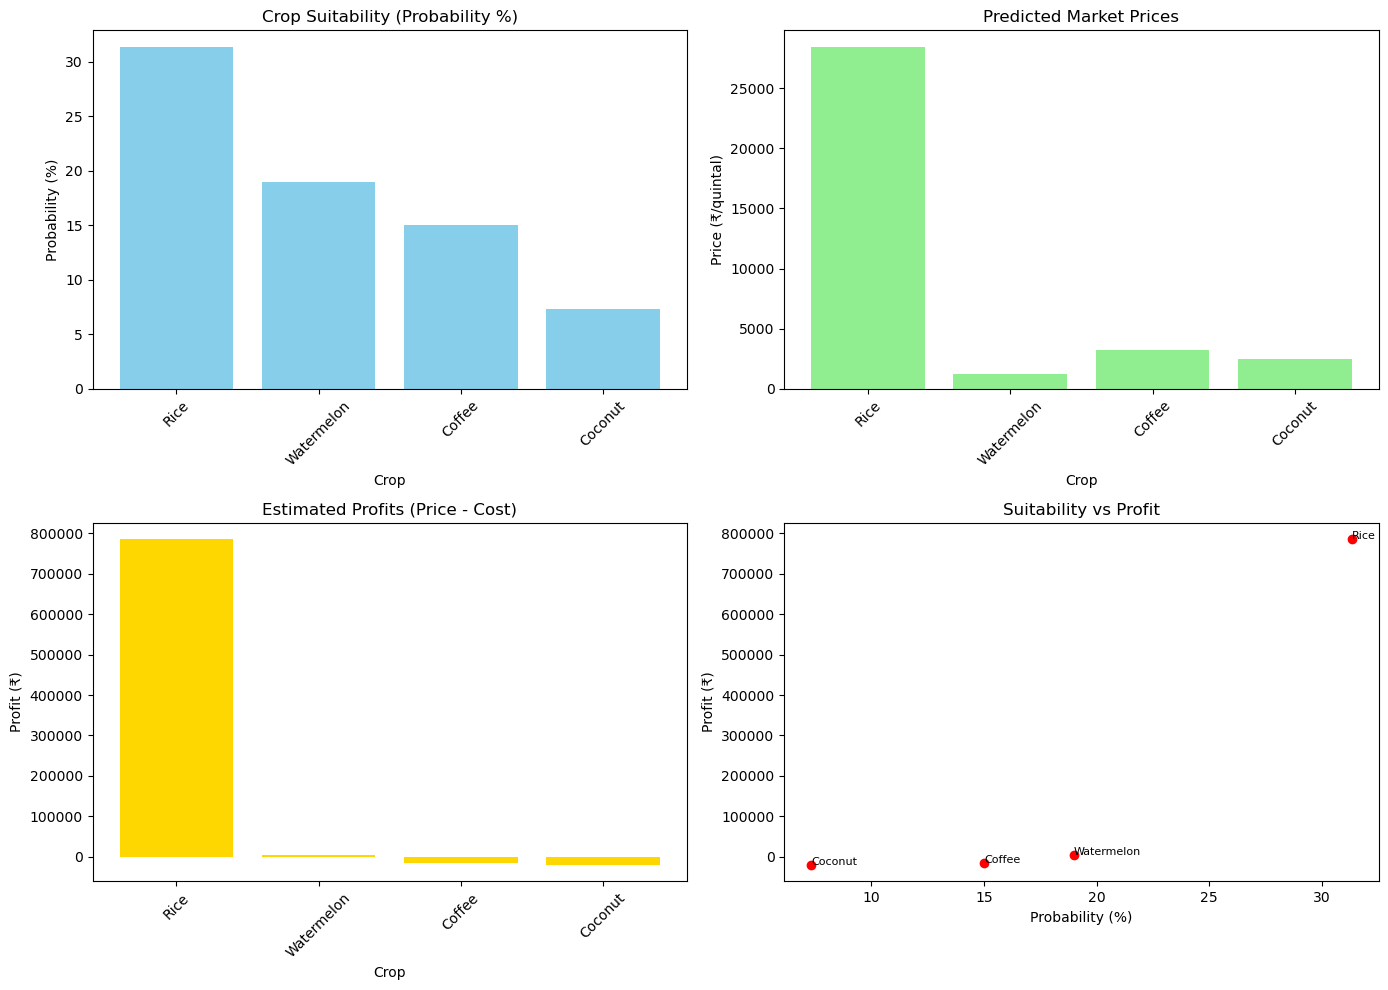

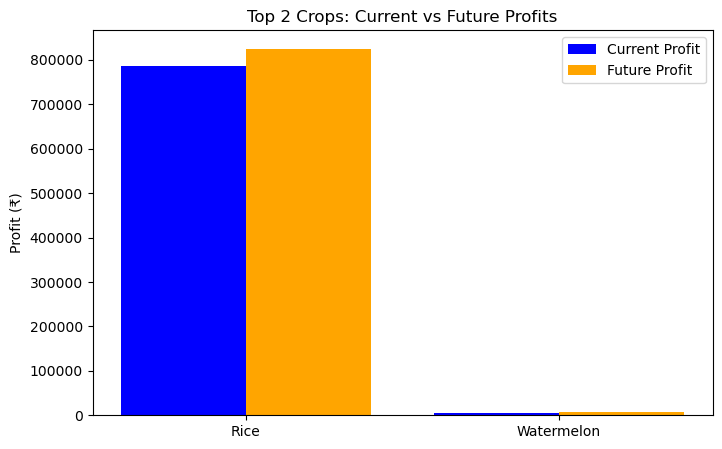

In [21]:
# Dashboard: Visualize Recommendations
import matplotlib.pyplot as plt

# Assuming result is from the example
crops = [rec['crop'] for rec in result['all_recommendations']]
probs = [rec['probability'] for rec in result['all_recommendations']]
prices = [rec['predicted_price'] or 0 for rec in result['all_recommendations']]
profits = [rec['profit'] for rec in result['all_recommendations']]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart for probabilities
ax1.bar(crops, probs, color='skyblue')
ax1.set_title('Crop Suitability (Probability %)')
ax1.set_ylabel('Probability (%)')
ax1.set_xlabel('Crop')
ax1.tick_params(axis='x', rotation=45)

# Bar chart for prices
ax2.bar(crops, prices, color='lightgreen')
ax2.set_title('Predicted Market Prices')
ax2.set_ylabel('Price (₹/quintal)')
ax2.set_xlabel('Crop')
ax2.tick_params(axis='x', rotation=45)

# Bar chart for profits
ax3.bar(crops, profits, color='gold')
ax3.set_title('Estimated Profits (Price - Cost)')
ax3.set_ylabel('Profit (₹)')
ax3.set_xlabel('Crop')
ax3.tick_params(axis='x', rotation=45)

# Scatter plot: Probability vs Profit
ax4.scatter(probs, profits, color='red')
ax4.set_title('Suitability vs Profit')
ax4.set_xlabel('Probability (%)')
ax4.set_ylabel('Profit (₹)')
for i, crop in enumerate(crops):
    ax4.annotate(crop, (probs[i], profits[i]), fontsize=8)

plt.tight_layout()
plt.show()

# Highlight top 2
top_crops = [rec['crop'] for rec in result['top_recommendations']]
top_profits = [rec['profit'] for rec in result['top_recommendations']]
top_future_profits = [rec['future_profit'] for rec in result['top_recommendations']]

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(top_crops))
ax.bar(x, top_profits, width=0.4, label='Current Profit', color='blue', align='center')
ax.bar([i + 0.4 for i in x], top_future_profits, width=0.4, label='Future Profit', color='orange', align='center')
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(top_crops)
ax.set_title('Top 2 Crops: Current vs Future Profits')
ax.set_ylabel('Profit (₹)')
ax.legend()
plt.show()

In [24]:
# Test with multiple examples
test_samples = [
    {"N":90,"P":22,"K":43,"temperature":32.88,"humidity":82.0,"ph":6.5,"rainfall":202.93,"state":"Karnataka","season":"Kharif"},  # Original
    {"N":60,"P":55,"K":45,"temperature":22.0,"humidity":90.0,"ph":5.5,"rainfall":100.0,"state":"West Bengal","season":"Kharif"},  # Rice-like
    {"N":20,"P":30,"K":10,"temperature":25.0,"humidity":65.0,"ph":7.0,"rainfall":50.0,"state":"Maharashtra","season":"Rabi"},   # Maize-like
    {"N":40,"P":20,"K":30,"temperature":30.0,"humidity":70.0,"ph":6.0,"rainfall":150.0,"state":"Punjab","season":"Kharif"}, # Cotton-like
    {"N":100,"P":50,"K":50,"temperature":25.0,"humidity":80.0,"ph":6.0,"rainfall":200.0,"state":"Tamil Nadu","season":"Zaid"}, # High nutrient
]

all_results = []
for i, sample in enumerate(test_samples, 1):
    print(f"\n--- Example {i} ---")
    print(f"Input: N={sample['N']}, P={sample['P']}, K={sample['K']}, Temp={sample['temperature']}, Hum={sample['humidity']}, pH={sample['ph']}, Rain={sample['rainfall']}, State={sample['state']}, Season={sample['season']}")
    result = integrated_recommend(sample)
    all_results.append((sample, result))
    print("Top 2 Recommendations for Better Profits and Growth:")
    for rec in result["top_recommendations"]:
        print(f"- {rec['crop']}: Prob {rec['probability']}%, Price ₹{rec['predicted_price']:.2f}, Cost ₹{rec['cultivation_cost']}, Profit ₹{rec['profit']:.2f}")


--- Example 1 ---
Input: N=90, P=22, K=43, Temp=32.88, Hum=82.0, pH=6.5, Rain=202.93, State=Karnataka, Season=Kharif
Top 2 Recommendations for Better Profits and Growth:
- Rice: Prob 31.33%, Price ₹28394.83, Cost ₹15000, Profit ₹785450.25
- Watermelon: Prob 19.0%, Price ₹1258.44, Cost ₹20000, Profit ₹5168.77

--- Example 2 ---
Input: N=60, P=55, K=45, Temp=22.0, Hum=90.0, pH=5.5, Rain=100.0, State=West Bengal, Season=Kharif
Top 2 Recommendations for Better Profits and Growth:
- Rice: Prob 26.08%, Price ₹12872.30, Cost ₹15000, Profit ₹347870.23
- Papaya: Prob 34.75%, Price ₹7941.68, Cost ₹60000, Profit ₹98833.62

--- Example 3 ---
Input: N=20, P=30, K=10, Temp=25.0, Hum=65.0, pH=7.0, Rain=50.0, State=Maharashtra, Season=Rabi
Top 2 Recommendations for Better Profits and Growth:
- Orange: Prob 22.0%, Price ₹12843.11, Cost ₹30000, Profit ₹226862.16
- Mango: Prob 9.56%, Price ₹10747.25, Cost ₹45000, Profit ₹169945.09

--- Example 4 ---
Input: N=40, P=20, K=30, Temp=30.0, Hum=70.0, pH=6.0, 

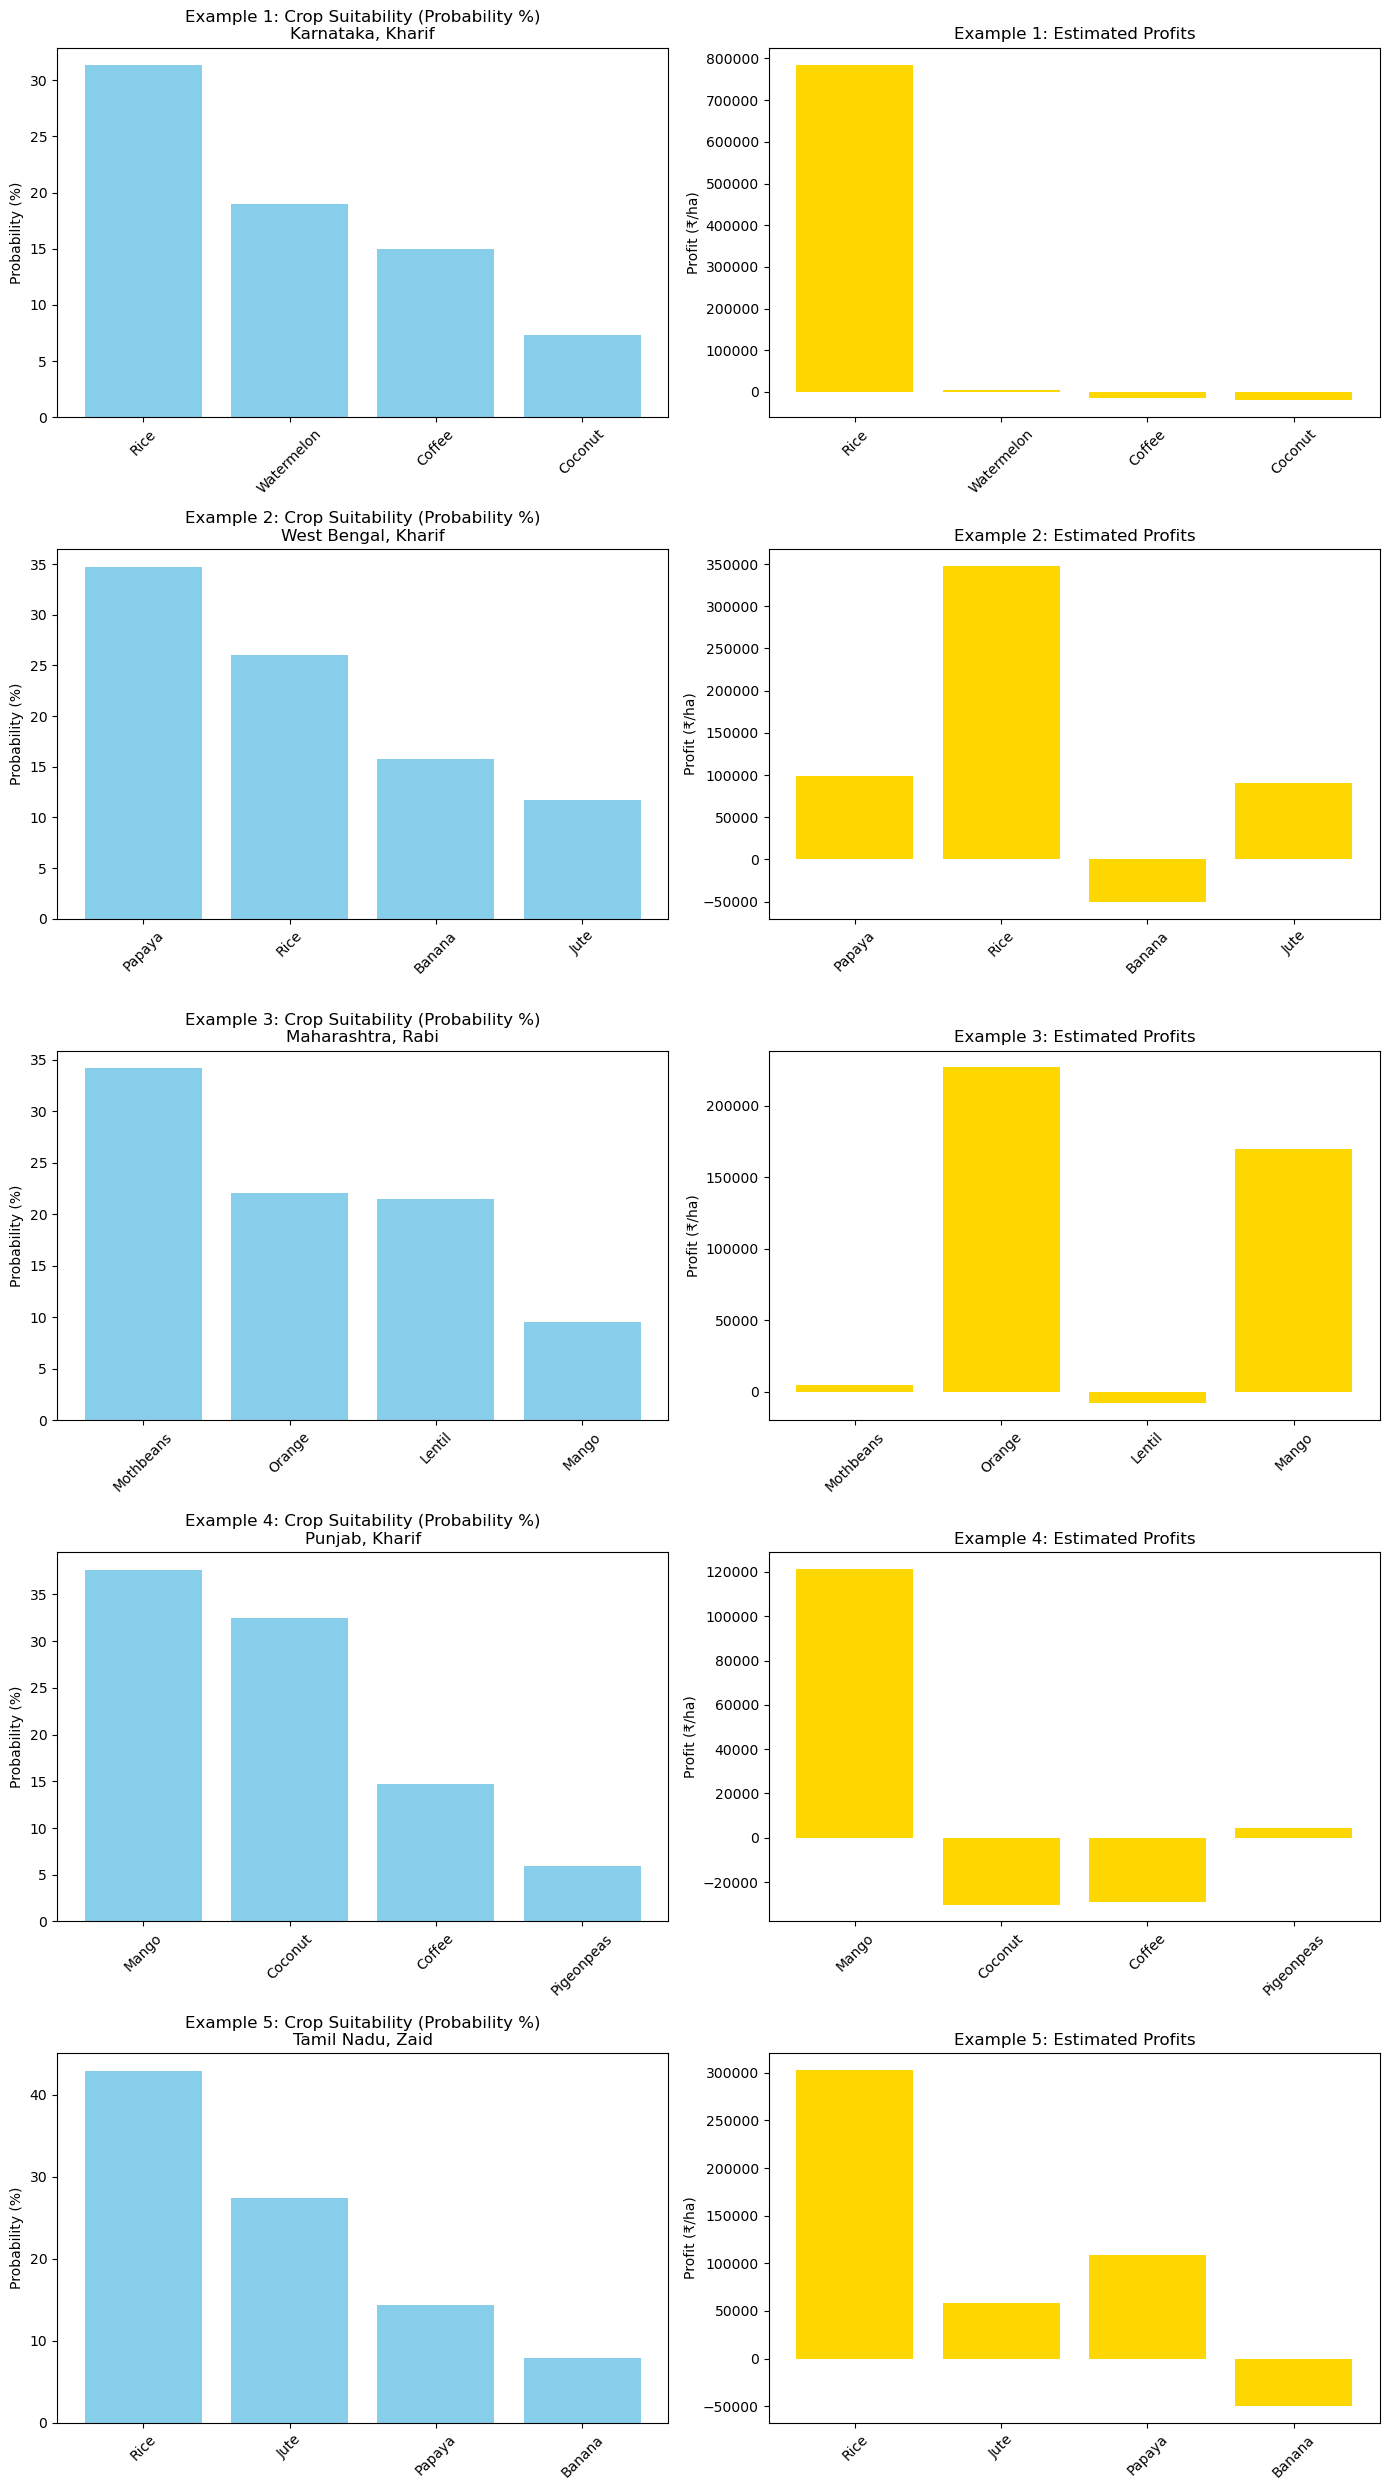

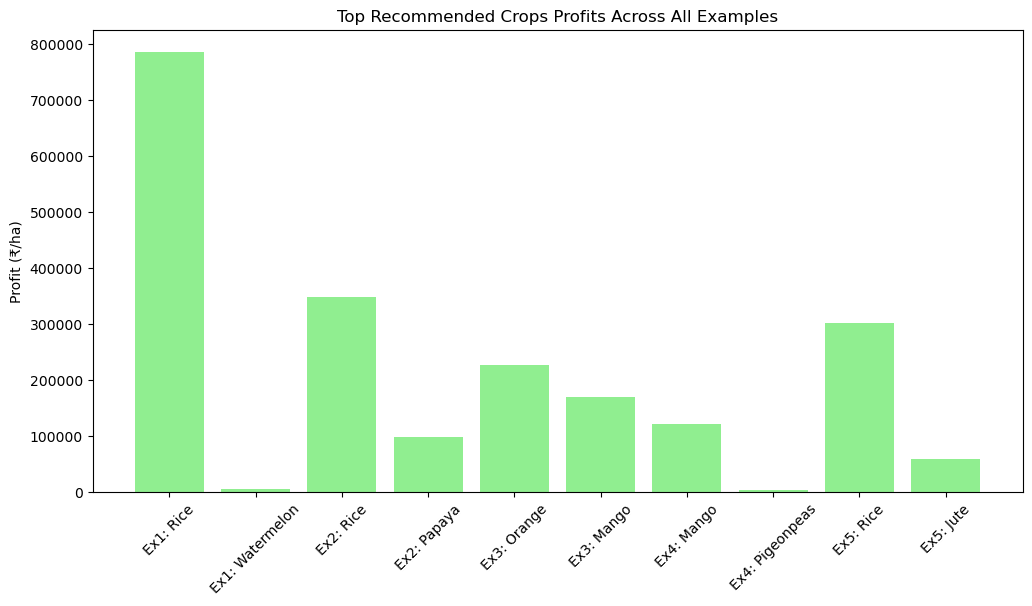

In [25]:
# Plot results for all test samples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(all_results), 2, figsize=(14, 5 * len(all_results)))

if len(all_results) == 1:
    axes = [axes]

for i, (sample, result) in enumerate(all_results):
    crops = [rec['crop'] for rec in result['all_recommendations']]
    probs = [rec['probability'] for rec in result['all_recommendations']]
    profits = [rec['profit'] for rec in result['all_recommendations']]
    
    # Bar chart for probabilities
    axes[i][0].bar(crops, probs, color='skyblue')
    axes[i][0].set_title(f'Example {i+1}: Crop Suitability (Probability %)\n{sample["state"]}, {sample["season"]}')
    axes[i][0].set_ylabel('Probability (%)')
    axes[i][0].tick_params(axis='x', rotation=45)
    
    # Bar chart for profits
    axes[i][1].bar(crops, profits, color='gold')
    axes[i][1].set_title(f'Example {i+1}: Estimated Profits')
    axes[i][1].set_ylabel('Profit (₹/ha)')
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary plot: Top crops across all examples
top_crops_all = []
top_profits_all = []
labels = []

for i, (sample, result) in enumerate(all_results):
    for rec in result['top_recommendations']:
        top_crops_all.append(rec['crop'])
        top_profits_all.append(rec['profit'])
        labels.append(f'Ex{i+1}: {rec["crop"]}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(labels, top_profits_all, color='lightgreen')
ax.set_title('Top Recommended Crops Profits Across All Examples')
ax.set_ylabel('Profit (₹/ha)')
ax.tick_params(axis='x', rotation=45)
plt.show()

In [26]:
# Check Rice yields across all seasons
print("="*60)
print("RICE YIELDS ANALYSIS (kg/ha)")
print("="*60)

rice_yields = {k: v for k, v in yield_dict.items() if 'Rice' in k[0]}
for (crop, season), yield_val in sorted(rice_yields.items()):
    print(f"{crop} - {season}: {yield_val:.2f} kg/ha ({yield_val/100:.2f} quintals/ha)")

print("\n" + "="*60)
print("RECOMMENDATIONS SHOWING RICE YIELDS")
print("="*60)

for i, (sample, result) in enumerate(all_results):
    print(f"\nExample {i+1} ({sample['state']}, {sample['season']}):")
    rice_recs = [r for r in result['all_recommendations'] if 'Rice' in r['crop']]
    if rice_recs:
        for rec in rice_recs:
            print(f"  {rec['crop']}: Yield={rec['yield_kg_per_ha']:.0f} kg/ha ({rec['yield_kg_per_ha']/100:.2f} quintals/ha), Revenue=₹{rec['revenue']:.2f}, Profit=₹{rec['profit']:.2f}")
    else:
        print("  No rice in recommendations")


RICE YIELDS ANALYSIS (kg/ha)
Rice - Kharif: 2819.00 kg/ha (28.19 quintals/ha)
Rice - Rabi: 3606.00 kg/ha (36.06 quintals/ha)
Rice - Summer: 3391.00 kg/ha (33.91 quintals/ha)

RECOMMENDATIONS SHOWING RICE YIELDS

Example 1 (Karnataka, Kharif):
  Rice: Yield=2819 kg/ha (28.19 quintals/ha), Revenue=₹800450.25, Profit=₹785450.25

Example 2 (West Bengal, Kharif):
  Rice: Yield=2819 kg/ha (28.19 quintals/ha), Revenue=₹362870.23, Profit=₹347870.23

Example 3 (Maharashtra, Rabi):
  No rice in recommendations

Example 4 (Punjab, Kharif):
  No rice in recommendations

Example 5 (Tamil Nadu, Zaid):
  Rice: Yield=2000 kg/ha (20.00 quintals/ha), Revenue=₹317846.07, Profit=₹302846.07
